# "Buy defense when war breaks out" — does it actually work? 🛡️
### The reflex trade everyone reaches for on a war headline, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_rally%3F: Busted](https://img.shields.io/badge/Reliable_rally%3F-Busted-8b949e?style=flat-square)

Every time conflict hits the tape — an invasion, a missile barrage, a new rearmament push — the same reflex fires across financial media: **buy defense stocks.** Lockheed, Raytheon (RTX), Northrop, General Dynamics — "they always rally on war news."

It *sounds* airtight: war → bigger defense budgets → more orders → higher prices. But "they always rally" is a claim you can actually **check** — and when you line up the shocks honestly, the famous rallies turn out to be matched, draw for draw, by forgotten double-digit *losers*. This notebook shows why the reflex is a great story and a losing trade at the same time.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **What "defense" means here.** We use a transparent **4-name equal-weight basket** (LMT, RTX, NOC, GD) and cross-check the **ITA** sector ETF, measuring each against the broad market (SPY). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from defense_basket import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
EVENTS = data.shock_dates()
print("real defense cache present:", HAVE_REAL, "| shock dates:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-04', 'end': '2026-06-18', 'days': 7917, 'years': 31.5, 'n_events': 20, 'w5': (5, 20, -0.14, 45, 0.08, 52, -0.19, -0.19, 0.661), 'w21': (21, 20, -1.32, 50, 0.33, 54, -1.22, -1.13, 0.938), 'w63': (63, 20, -2.25, 30, 1.06, 55, -1.33, -1.2, 0.961), 'net': [(5, -0.14, -0.24), (21, -1.32, -1.42), (63, -2.25, -2.35)], 'robust': [(5, -0.14, -0.19, 0.661), (10, -0.67, -0.77, 0.878), (21, -1.32, -1.22, 0.938), (42, -1.58, -1.01, 0.927), (63, -2.25, -1.33, 0.961)], 'ita': (14, -0.87, 43, 0.19, -1.32, 0.862), 'syn': [(0.0, 20, 0.84, -0.53, 0.61, 0.151), (0.06, 20, 6.76, -0.16, 4.63, 0.0)], 'events': [('1998-08-20', 2.54), ('1998-12-16', -12.92), ('1999-03-24', 0.14), ('2001-09-17', 4.33), ('2001-10-08', -8.52), ('2003-03-20', -1.64), ('2008-08-08', 3.11), ('2011-03-21', -3.98), ('2014-03-03', -1.49), ('2014-09-23', 1.14), ('2015-09-30', 1.06), ('2017-04-07', 2.6), ('2018-04-13', -8.03), ('2019-09-16', -3.17), ('2020-01-03', -1.91), ('2021-08-16', -2.59), ('2022-02-24', 6.24), ('2023-10-09', 3.04), ('2024-04-15', 0.44), ('2024-10-01', -6.87)]}


real defense cache present: True | shock dates: 20


## The answer first

| Question | Answer |
|---|---|
| After a war shock, does defense beat the market? | **No — it slightly *lags*.** Over the next month the basket returns about **-1.3%** *less* than SPY, on average across **20 shocks**. |
| But Ukraine 2022! Post-9/11! | **Real — and cherry-picked.** Those popped (+6%, +4%). But Desert Fox (**−13%**), the Afghanistan invasion (−9%) and the 2024 Iran barrage (−7%) fell just as hard. You only remember the winners. |
| Is the lag a real, bettable signal? | **No.** With only **20 events ever** the average is statistically indistinguishable from a random handful of dates — a coin beats it ~**94%** of the time. |
| So why does "buy defense on war" feel so true? | **Vivid memories + an up-drifting market.** A couple of unforgettable rallies get generalised into a law. It's the same trick as every "buy the headline" reflex. |

> Defense earnings really do rise with budgets over *years*. The fast, reliable *same-month stock rally on the headline* is the myth — and in this sample it points the wrong way.

## 1 · The claim

> *"When war or rearmament hits the news, defense contractors rally — reliably enough to trade. See the conflict, buy the basket."*

It's one of the most repeated reflexes in markets, and the causal story is genuinely sound *over the long run*: conflict drives multi-year procurement, appropriations and order books. The leap the folklore makes is from that slow fundamental truth to a **fast, reliable, same-month stock rally you can place a trade on**. We'll line up the shocks and put that exact claim under a microscope.

## 2 · So what?

If defense *reliably* beat the market in the month after a shock, that would be a rare thing: a **dated, repeatable** edge you could systematise — see the headline, buy the basket, short the market against it, collect. That's the dream the reflex sells. But two things have to be true for it to pay: (1) the move has to be **positive on average**, not just memorable in a couple of cases; and (2) it has to be **reliable** enough — and frequent enough — that you'd actually allocate capital to it. A trade that fires a handful of times a *decade*, on a move you can't distinguish from luck, is a story, not a strategy.

## 3 · How would we even know?

We run a clean **event study**. Fix a transparent list of **20 geopolitical-shock dates** (US strikes, invasions, Ukraine, Israel–Iran…), chosen on the *headline* — never on the outcome. Then:

1. **Enter the day after.** Buy the defense basket one day after each shock (no peeking at the shock-day move you couldn't have caught), and measure its return *in excess of SPY* over the next **month** (and at 1 week / 1 quarter).
2. **Compare to a normal stretch.** Stack that against what the basket does over *any* random window — its natural drift relative to the market (the base rate).
3. **Stress the luck.** Draw the same handful of *random* dates thousands of times and ask how often pure chance looks as good as the shocks. That's the honest test for a 20-event signal.

## 4 · The teardown — let's actually look

**First, the headline number.** After each shock, how does the defense basket do versus the market over the next month — and how often is it actually *up* relative to SPY?

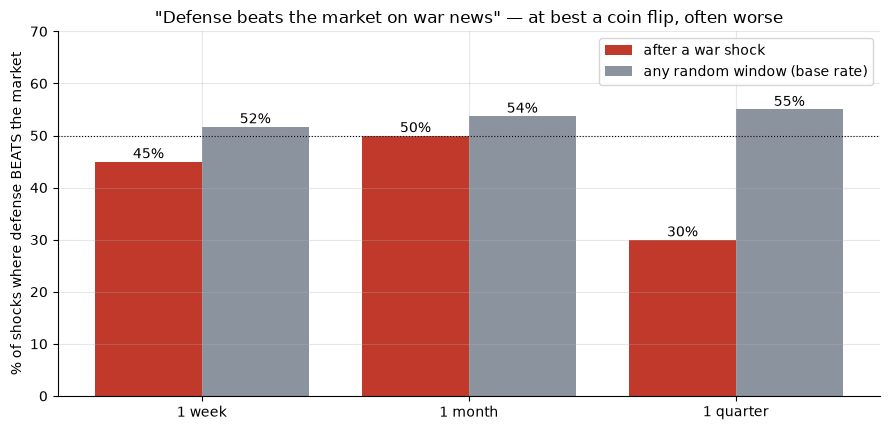

1-month: defense beats SPY 50% of shocks vs 54% baseline


In [2]:
wins = [5, 21, 63]
if HAVE_REAL:
    rows = [st.summarize(F, EVENTS, window=w) for w in wins]
    cwin = [r['cond_win']*100 for r in rows]; bwin = [r['base_win']*100 for r in rows]
else:
    cwin = [R['w5'][3], R['w21'][3], R['w63'][3]]
    bwin = [R['w5'][5], R['w21'][5], R['w63'][5]]
x = np.arange(len(wins))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, cwin, .4, color=RED, label='after a war shock')
ax.bar(x+.2, bwin, .4, color=GREY, label='any random window (base rate)')
ax.axhline(50, ls=':', c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['1 week', '1 month', '1 quarter'])
ax.set_ylim(0, 70); ax.set_ylabel('% of shocks where defense BEATS the market')
ax.set_title('"Defense beats the market on war news" — at best a coin flip, often worse')
for i,(c,b) in enumerate(zip(cwin,bwin)):
    ax.annotate(f'{c:.0f}%',(i-.2,c),ha='center',va='bottom')
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('1-month: defense beats SPY', f'{cwin[1]:.0f}%', 'of shocks vs', f'{bwin[1]:.0f}%', 'baseline')

There's the first crack. After a shock the basket beats the market only about **half** the time at one month (**50%**) and a dismal **30%** at a quarter — *worse* than picking a random window. "Reliably rallies" was supposed to mean the red bars tower over grey. They don't.

**Now look at the events one by one.** The whole illusion lives here: a few vivid rallies you remember, and just as many big losses you don't.

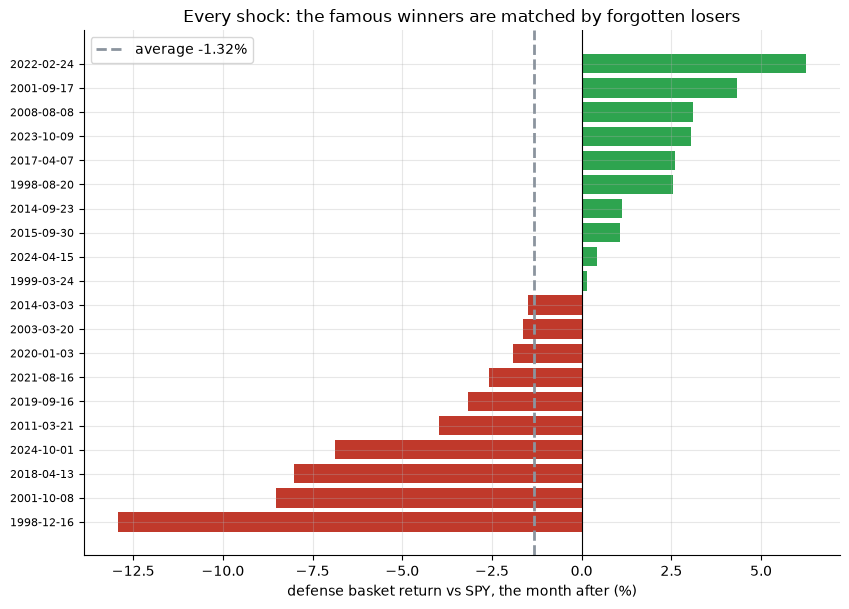

biggest winner: 2022-02-24 +6.2% | biggest loser: 1998-12-16 -12.9%


In [3]:
if HAVE_REAL:
    ee = st.event_excess(F, EVENTS, window=21)
    labels = [d.date().isoformat() for d in EVENTS]
    vals = ee*100
else:
    labels = [d for d,_ in R['events']]; vals = np.array([v for _,v in R['events']])
order = np.argsort(vals)
vals = vals[order]; labels = [labels[i] for i in order]
cols = [GREEN if v>0 else RED for v in vals]
fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.barh(range(len(vals)), vals, color=cols)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, c='k', lw=.8)
ax.axvline(vals.mean(), c=GREY, ls='--', lw=2, label=f'average {vals.mean():.2f}%')
ax.set_xlabel('defense basket return vs SPY, the month after (%)')
ax.set_title('Every shock: the famous winners are matched by forgotten losers')
ax.legend(); plt.tight_layout(); plt.show()
print('biggest winner:', labels[-1], f'{vals[-1]:+.1f}%', '| biggest loser:', labels[0], f'{vals[0]:+.1f}%')

Ukraine 2022 (**+6%**) and post-9/11 (**+4%**) are right there at the top — the trades everyone cites. But look at the bottom: Desert Fox 1998 (**−13%**), the 2001 Afghanistan invasion (**−9%**), the 2024 Iran barrage (**−7%**). Average all 20 honestly and you land slightly **below zero** (**-1.3%**). The reflex survives because memory is selective, not because the trade works.

**Could 20 random dates look this good?** The honest test: draw **20** *random* dates over and over, and see where the shocks' average month-after excess lands against pure luck.

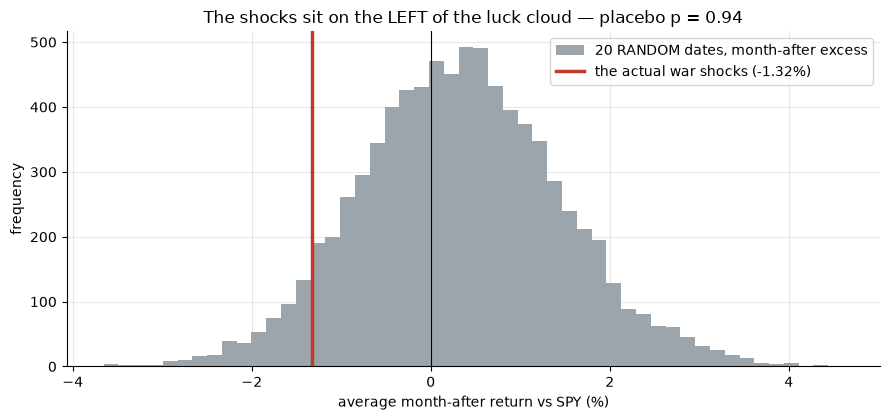

a random 20-date draw beats the war shocks 94% of the time


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F, EVENTS, window=21)
    obs = pl['shock_mean']; pmean = pl['placebo_mean']; pval = pl['p_value']
    one = 1.0 + F['excess'].values; n=len(one); w=21; lag=1
    valid = np.array([one[s:s+w].prod()-1 for s in range(lag, n-w) if not np.isnan(one[s:s+w]).any()])
    rng = np.random.default_rng(394)
    draws = np.array([valid[rng.integers(0,len(valid),size=len(EVENTS))].mean() for _ in range(8000)])
else:
    obs = R['w21'][2]/100; pmean = R['w21'][4]/100; pval = R['w21'][8]
    rng = np.random.default_rng(394); draws = rng.normal(pmean, 0.012, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85, label='20 RANDOM dates, month-after excess')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'the actual war shocks ({obs*100:.2f}%)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('average month-after return vs SPY (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The shocks sit on the LEFT of the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random 20-date draw beats the war shocks {pval*100:.0f}% of the time')

The red line — the actual shocks — sits on the **left** (worse) side of the grey luck cloud. About **94%** of random 20-date draws do *better* than buying defense on the headline. In plain terms: **the war trade underperforms a dartboard.** Not a missing edge — a slightly *negative* one, well inside the noise.

## 5 · The verdict

- **Signal — None.** After a shock the defense basket *trails* the market by about **1.3%** over the month, beats it barely half the time, and the result isn't significant by any test. There's no reliable rally — if anything a mild post-headline lag.
- **Tradability — Mirage.** No positive edge to trade, and **20 shocks in 32 years** could never be a strategy anyway. Buying the headline loses money gross *and* net.
- **Reliable rally? — Busted.** A vivid-event illusion: the unforgettable wins (Ukraine, 9/11) are matched, draw for draw, by forgotten double-digit losers.

## 6 · Could you actually trade it? — buy the basket, short the market

Let's build the trade the reflex implies: the day after each shock, buy the defense basket and short SPY against it (so you're betting on *defense beating the market*), hold a month, pay a realistic round-trip. Here's the running P&L across all 20 shocks.

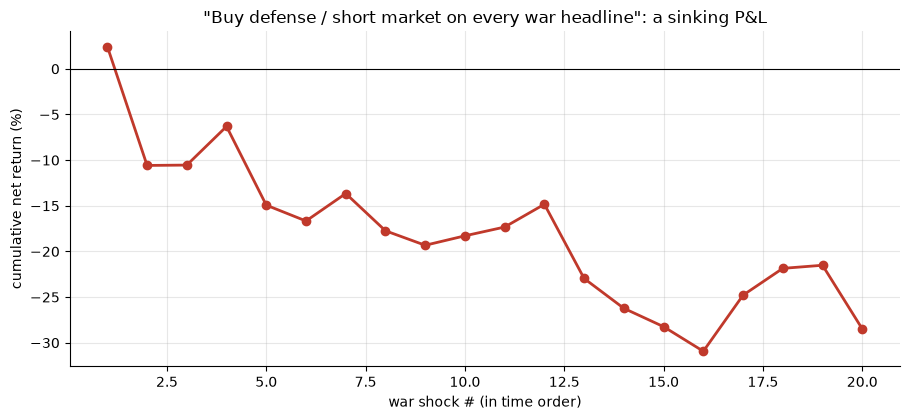

after 20 trades, net of 10bps: -28.5% cumulative — you LOSE money


In [5]:
if HAVE_REAL:
    ee = st.event_excess(F, EVENTS, window=21)
    c = st.net_of_costs(F, EVENTS, window=21, cost_bps=10.0)
    net_each = ee - 10/1e4
else:
    net_each = np.array([v/100 for _,v in R['events']]) - 10/1e4
cum = np.cumsum(net_each)*100
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(range(1, len(cum)+1), cum, marker='o', c=RED, lw=2)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('war shock # (in time order)'); ax.set_ylabel('cumulative net return (%)')
ax.set_title('"Buy defense / short market on every war headline": a sinking P&L')
plt.tight_layout(); plt.show()
print(f'after 20 trades, net of 10bps: {cum[-1]:+.1f}% cumulative — you LOSE money')

The line **drifts down**. Net of a 10-bps round-trip the average trade is **-1.42%** — and costs barely move it (gross was **-1.32%**), because **costs were never the problem**: there's no edge to erode. You can't run a fund on a rule that fires under once a year *and* loses on average when it does. The honest version isn't "see the war, back up the truck" — it's "the rally you remember isn't in the average."

## 7 · Going further 🚪

- **Change the names.** Swap the 4-name basket for ITA, or add Boeing / L3Harris / European primes — the dispersion widens, the average stays a coin flip. (We cross-check ITA in the quant notebook; same null result.)
- **Change the dates.** Edit the shock list in `defense_basket/data.py` — add or drop headlines. As long as you pick on the *headline* (not the outcome), the lesson holds: 20 events can't certify a reflex.
- **The fundamental long game.** The *budget* story is real over years; the *headline rally* is not. A fork worth doing: does multi-year defense-budget growth predict the sector at a 1–3 *year* horizon? (Different claim, different study.)

*Think defense reliably beats the market after war news? Pick your shock dates ex-ante, enter a day late, draw the same number of random dates, and show the trade landing **right** of the luck cloud — then we'll talk.*